# UK Flood Risk Exposure Analysis using Python #

### Objective: 
An analysis of UK Postcode level flood risk data to demonstrate catastrophe risk and exposure management concepts, including: flood hazard analysis, exposure aggregation, concentration analysis and simulated loss estimation.  

### Tools used: 
- Python
- Jupyter Notebook
- Pandas
- Numpy
- Matplotlib

### Dataset - Open Flood Risk by Postcode Dataset 
The dataset contains postcode level flood risk classifications derived from the Enviornment Agency's 'Risk of Flooding from Rivers and Sea' dataset and Open Postcode Geo. Flood risk is categorised into four bands (High, Medium, Low, and Very Low) and includes postcode-level geographic coordinates. The working dataset used for this project was accessed via Kaggle. 

### Limitations
Real insurance portfolio and exposure data are proprietary and not publicly available. Due to this, insured values were simulated for the purposes of this project to demonstrate exposure aggregation, concentration analysis and catastrophe-style loss estimation techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fr=pd.read_csv('/Users/sam_bradberry/Documents/Data Science & Python learning/Data to work with/open_flood_risk_by_postcode.csv')
fr.head()

,index,TR23 0PR,\N,None,\N.1,\N.2,\N.3,87897,15021,49.953605,-6.352647
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


### Data Quality Checks

In [3]:
fr.info

<bound method DataFrame.info of            index  TR23 0PR       \N None            \N.1        \N.2 \N.3  \
0              0  TR23 0WA       \N  NaN              \N          \N   \N   
1              1  TR22 0PL       \N  NaN              \N          \N   \N   
2              2  TR24 0QE       \N  NaN              \N          \N   \N   
3              3  TR24 0QL       \N  NaN              \N          \N   \N   
4              4  TR24 0QB       \N  NaN              \N          \N   \N   
...          ...       ...      ...  ...             ...         ...  ...   
1443989  1443989  NR32 1UX  1419271  Low  Town to Street  2013-12-22   No   
1443990  1443990  NR32 1XJ  1419271  Low  Town to Street  2013-12-22   No   
1443991  1443991  NR32 1UZ  1419271  Low  Town to Street  2013-12-22   No   
1443992  1443992  NR32 1XQ  1419271  Low  Town to Street  2013-12-22   No   
1443993  1443993  NR32 1XH  1419271  Low  Town to Street  2013-12-22   No   

          87897   15021  49.953605  -6.3526

In [4]:
fr.columns

Index(['index', 'TR23 0PR', '\N', 'None', '\N.1', '\N.2', '\N.3', '87897',
       '15021', '49.953605', '-6.352647'],
      dtype='object')

In [5]:
fr.shape

(1443994, 11)

### Data Cleaning
- Data imported incorrectly with the first row interpreted as headers.
- Reloading dataset with header=None, renaming columns and preparing the dataset for analysis.

In [6]:
fr.columns=['Index','Postcode','FID','PROB_4BAND','SUITABILITY','PUB_DATE','Risk_For_Insurance_SOP','Easting','Northing','Latitude','Longitude']

fr.head()

,Index,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


In [7]:
fr=fr.iloc[:,1:]

In [8]:
fr.shape

(1443994, 10)

In [9]:
fr.head()

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


In [10]:
fr.info

<bound method DataFrame.info of          Postcode      FID PROB_4BAND     SUITABILITY    PUB_DATE  \
0        TR23 0WA       \N        NaN              \N          \N   
1        TR22 0PL       \N        NaN              \N          \N   
2        TR24 0QE       \N        NaN              \N          \N   
3        TR24 0QL       \N        NaN              \N          \N   
4        TR24 0QB       \N        NaN              \N          \N   
...           ...      ...        ...             ...         ...   
1443989  NR32 1UX  1419271        Low  Town to Street  2013-12-22   
1443990  NR32 1XJ  1419271        Low  Town to Street  2013-12-22   
1443991  NR32 1UZ  1419271        Low  Town to Street  2013-12-22   
1443992  NR32 1XQ  1419271        Low  Town to Street  2013-12-22   
1443993  NR32 1XH  1419271        Low  Town to Street  2013-12-22   

        Risk_For_Insurance_SOP  Easting  Northing   Latitude  Longitude  
0                           \N    87903     15077  49.954111  -6.

### Flood Hazard Distribution

In [11]:
fr.describe(include='all')

,Postcode,FID,PROB_4BAND,SUITABILITY,PUB_DATE,Risk_For_Insurance_SOP,Easting,Northing,Latitude,Longitude
count,1443994,1443994,122007,1443994,1443994,1443994,1.443994e+06,1.443994e+06,1.443994e+06,1.443994e+06
unique,1443994,28959,4,6,20,3,NaN,NaN,NaN,NaN
top,TR23 0WA,\N,Low,\N,\N,\N,NaN,NaN,NaN,NaN
freq,1,1321987,80001,1321987,1321987,1321987,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,4.514074e+05,2.749507e+05,5.236327e+01,-1.252832e+00
std,NaN,NaN,NaN,NaN,NaN,NaN,8.767993e+04,1.307748e+05,1.180241e+00,1.268694e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,8.790300e+04,8.478000e+03,4.989517e+01,-6.352609e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,3.899580e+05,1.732300e+05,5.144678e+01,-2.150858e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,4.463150e+05,2.524580e+05,5.215679e+01,-1.314460e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,5.234398e+05,3.898560e+05,5.340280e+01,-2.142255e-01


In [12]:
fr['PROB_4BAND'].value_counts()

PROB_4BAND
Low         80001
Medium      24928
High        12305
Very Low     4773
Name: count, dtype: int64

### Exposure Aggregation and Modelling
As insurance portfolio data is not publicly available, simulated insured property values are randomly assigned (£75,000 - £1,000,000) to demonstrate exposure management concepts.

Text(0, 0.5, 'Number of Postcodes')

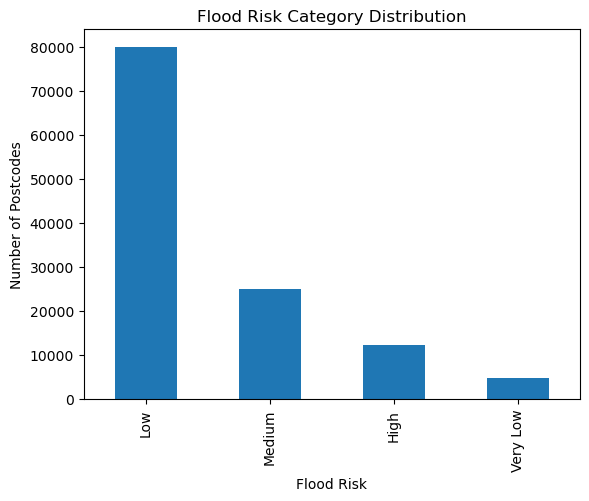

In [13]:
fr['PROB_4BAND'].value_counts().plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

Text(0, 0.5, 'Number of Postcodes')

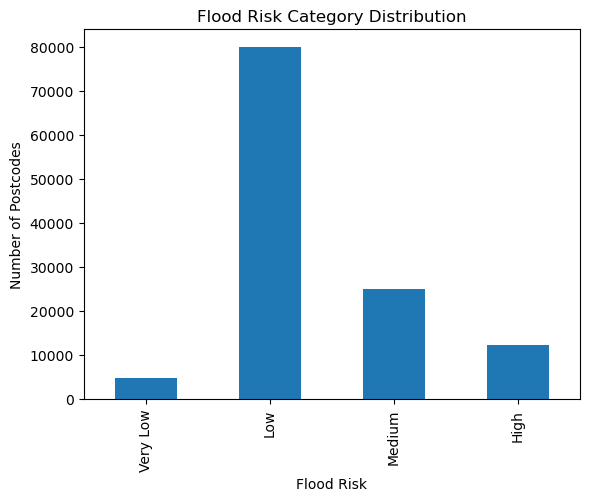

In [14]:
risk_order=['Very Low','Low','Medium','High']
risk_counts=fr['PROB_4BAND'].value_counts().reindex(risk_order)

risk_counts.plot(kind='bar')

plt.title('Flood Risk Category Distribution')
plt.xlabel('Flood Risk')
plt.ylabel('Number of Postcodes')

In [15]:
fr['Insured_Value']=np.random.randint(75000,1000000,size=len(fr))

In [16]:
risk_exposure=fr.groupby('PROB_4BAND')['Insured_Value'].sum()

print(risk_exposure)

PROB_4BAND
High         6566528516
Low         42995130453
Medium      13499693657
Very Low     2598690558
Name: Insured_Value, dtype: int64


Text(0.5, 0, 'Flood Risk')

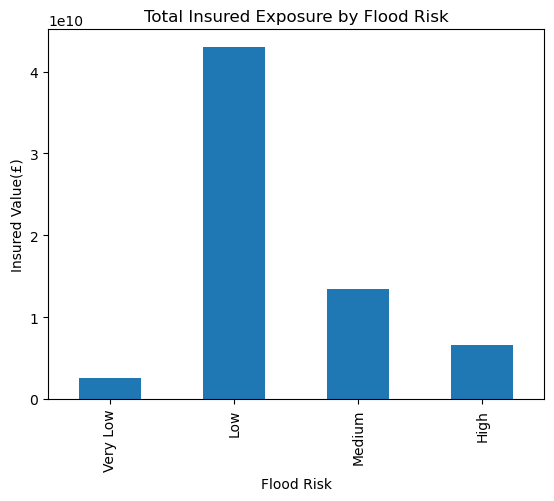

In [17]:
risk_order=['Very Low','Low','Medium','High']
risk_exposure=fr.groupby('PROB_4BAND')['Insured_Value'].sum().reindex(risk_order)

risk_exposure.plot(kind='bar')

plt.title('Total Insured Exposure by Flood Risk')
plt.ylabel('Insured Value(£)')
plt.xlabel('Flood Risk')

### Flood Loss Model
This loss model is applied using assumed damage ratios for each flood risk category (High to Very Low - 10%, 5%, 2% and 0.5% respectively). These assumptions are for the purposes of this workbook only and are not intended to represent real catastrophe model values.

In [18]:
loss_values={
    'High':0.10,
    'Medium':0.05,
    'Low':0.02,
    'Very Low':0.005}

In [19]:
fr['Loss']=fr['PROB_4BAND'].map(loss_values)

In [20]:
fr['Estimated_Loss']=fr['Insured_Value']*fr['Loss']

In [21]:
estimated_loss=fr.groupby('PROB_4BAND')['Estimated_Loss'].sum()

print(estimated_loss)

PROB_4BAND
High        6.566529e+08
Low         8.599026e+08
Medium      6.749847e+08
Very Low    1.299345e+07
Name: Estimated_Loss, dtype: float64


Text(0, 0.5, 'Estimated Loss(£)')

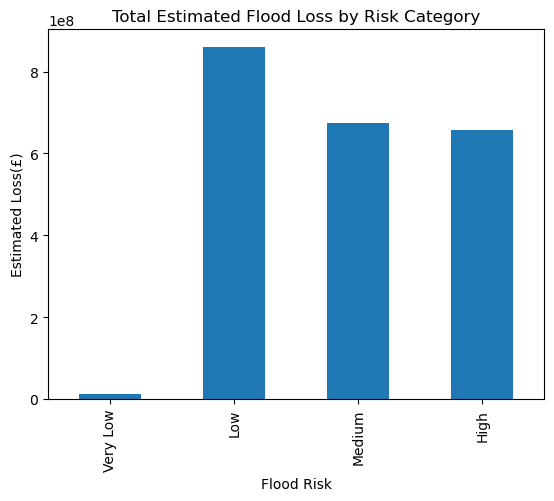

In [22]:
risk_order=['Very Low','Low','Medium','High']
estimated_loss=estimated_loss.reindex(risk_order)

estimated_loss.plot(kind='bar')

plt.title('Total Estimated Flood Loss by Risk Category')
plt.xlabel('Flood Risk')
plt.ylabel('Estimated Loss(£)')

Text(0, 0.5, '')

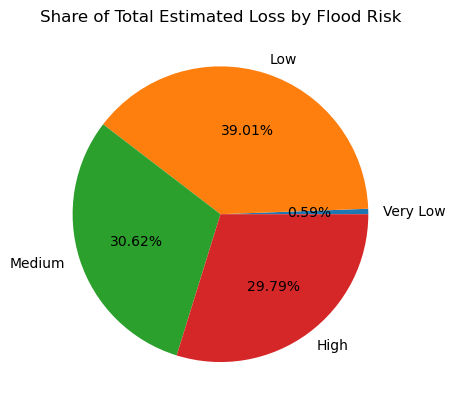

In [23]:
estimated_loss.plot(kind='pie',autopct='%1.2f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

Text(0, 0.5, '')

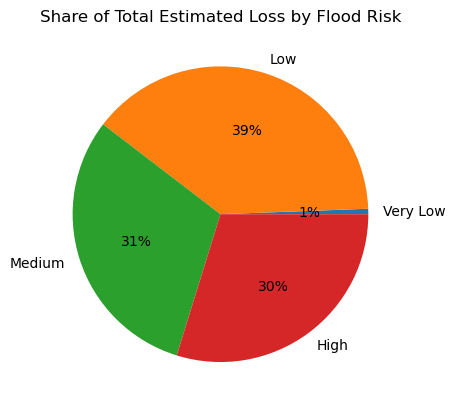

In [24]:
estimated_loss.plot(kind='pie',autopct='%1.0f%%')

plt.title('Share of Total Estimated Loss by Flood Risk')
plt.ylabel('')

### Exposure Concentrations
The following analysis identifies the postcode areas with the highest and lowest levels of insured exposure.

In [25]:
fr['Postcode_Area']=fr['Postcode'].str.split().str[0]

In [26]:
area_exposure=fr.groupby('Postcode_Area')['Insured_Value'].sum()

Text(0.5, 0, 'Insured Value (£)')

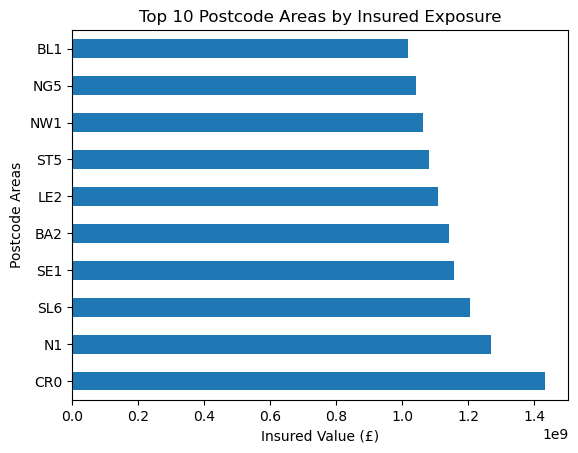

In [27]:
top10=area_exposure.sort_values(ascending=False).head(10)

top10.plot(kind='barh')

plt.title('Top 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas represent the largest concentrations of insured exposure to flood risk. These postcodes may warrant further review for managing potential loss.

Text(0.5, 0, 'Insured Value (£)')

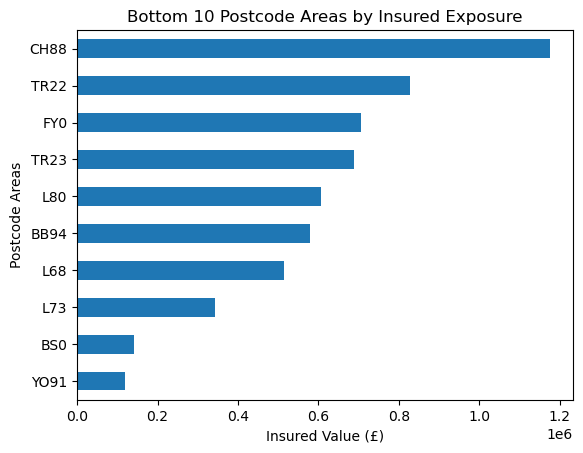

In [28]:
top10=area_exposure.sort_values(ascending=True).head(10)

top10.plot(kind='barh')

plt.title('Bottom 10 Postcode Areas by Insured Exposure')
plt.ylabel('Postcode Areas')
plt.xlabel('Insured Value (£)')

The above postcode areas contribute the least to the overall portfolio exposure. These postcodes therefore have a limited impact on loss potential.

### Full Distribution of Insurance Exposure using bins

Text(0, 0.5, 'Frequency')

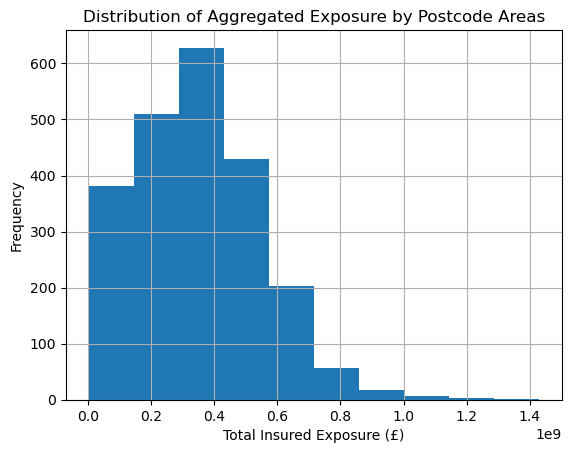

In [29]:
area_exposure.hist(bins=10)

plt.title('Distribution of Aggregated Exposure by Postcode Areas')
plt.xlabel('Total Insured Exposure (£)')
plt.ylabel('Frequency')

By narrowing the histogram bins to 10, the distribution of aggregated insured exposure becomes more clearly observable. The results indicate that the majority of postcode areas within the simulated portfolio contain relatively lower levels of aggregated insured exposure, while the frequency of postcode areas declines significantly as total exposure increases. This interpretation suggests a positively skewed exposure distribution, whereby a relatively small number of postcode areas contain disproportionately large concentrations of insured value. These higher concentration areas may represent greater risk during severe flood events, as shown when we combine this with the data of estimated losses- High Risk postcode areas, whilst distributed in a clear minority, present a disproportionately high contribution to potential loss.

### Conclusions

Key observations:
- The majority of UK postcodes fall within the low flood risk category.
- High-risk postcode areas contribute disproportionately to potential loss.

Future enhancements:
- Event-based flood scenarios.
- Geospatial Mapping.
- Probable Maximum Loss estimations
- Annual Average Loss calculations

Limitations:
- Simulated insured values.
- Loss assumptions were simplified.
- No event or catastrophe model was applied.